# 2.1 Preprocessing Pipeline

Prepares the basetable for modelling: leakage audit, imputation, walk-forward CV split, feature selection.

**Pipeline:** Gold → Gold  
**Input:** `Data/3_Gold/basetable_ultimate.csv`  
**Output:** `Data/3_Gold/basetable_preprocessed.csv`

<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Missing Value Imputation](#1-missing-value-imputation)
- [2. Walk-Forward Cross-Validation Structure](#2-walk-forward-cross-validation-structure)
- [3. Feature Selection](#3-feature-selection)
- [4. Save Preprocessed Basetable](#4-save-preprocessed-basetable)


## Setup

In [1]:
import sys, os
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import spearmanr
from Functions.data_splits import get_cv_folds, get_test_split, validate_no_leakage, print_fold_summary
from house_style import *
apply_style()

DATA_DIR  = os.path.join("..", "..", "Data", "3_Gold")
INPUT_CSV = os.path.join(DATA_DIR, "basetable_ultimate.csv")
OUTPUT_CSV = os.path.join(DATA_DIR, "basetable_preprocessed.csv")

TARGET_COL = "polymarket_trump_prob"
DATE_COL   = "date"
START_DATE = "2024-07-05"
N_SPLITS   = 3
GAP        = 1
TEST_DAYS  = 14

print("Imports OK")

Imports OK


In [2]:
raw = pd.read_csv(INPUT_CSV, parse_dates=[DATE_COL])
df  = raw[raw[DATE_COL] >= START_DATE].copy().reset_index(drop=True)
df  = df.sort_values(DATE_COL).reset_index(drop=True)

print(f"Rows after date filter  : {len(df)}")
print(f"Date range              : {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}")
print(f"Columns (incl. date)    : {df.shape[1]}")
df.head(3)

Rows after date filter  : 123
Date range              : 2024-07-05 → 2024-11-04
Columns (incl. date)    : 198


,date,polymarket_trump_prob,polymarket_trump_prob_lag1,days_to_election,is_weekend,weekday,campaign_week,days_since_last_event,bsky_total_posts,bsky_unique_authors,...,news_attention_asymmetry_7d_lag1,news_vader_leaning_gap_lag1,poll_margin_lag1,poll_market_divergence_lag1,gt_trump_lag1,gt_kamala_lag1,gt_trump_share_lag1,vix_lag1,sp500_return_1d_lag1,reddit_sentiment_gap_lag1
0,2024-07-05,0.625,0.605,123.0,0.0,4.0,1.0,NaN,41.0,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-07-06,0.625,0.625,122.0,1.0,5.0,1.0,NaN,24.0,20.0,...,NaN,-0.089014,NaN,NaN,3.0,1.0,0.75,12.48,0.005449,-0.063879
2,2024-07-07,0.605,0.625,121.0,1.0,6.0,1.0,NaN,29.0,17.0,...,NaN,-0.027437,-1.0,21.5,3.0,0.0,1.00,NaN,NaN,-0.078085


## 1. Missing Value Imputation

All imputation rules are deterministic — no statistics are borrowed from future rows.

| Columns | Strategy | Reason |
|---|---|---|
| Financial (`sp500`, `vix`, `oil`, …) | Forward-fill | Markets are closed on weekends/holidays; last known price carries forward |
| `days_since_last_event` (8 leading NaN) | Fill 30 | Jul 5–12 precedes the first event (Jul 13); 30 days is a neutral "long ago" prior |
| `poll_margin_change_7d` (8 leading NaN) | Fill 0 | No 7-day change available before sufficient poll data; 0 = no movement assumed |
| `poll_volatility_7d` (3 leading NaN) | Fill 0 | Same reasoning as above |
| News & Reddit columns (5–1 NaN) | Forward-fill, then fill 0 | Days with no coverage/scraping; ffill where prior data exists, 0 as neutral baseline |
| All remaining NaN | Forward-fill, then fill 0 | Catches lag columns and rolling windows at series start |

In [3]:
df_imp = df.copy()

# ── Step 1: Financial forward-fill ────────────────────────────────────────────
FINANCIAL_COLS = [
    "sp500", "oil", "vix", "bond_10y", "usd_index",
    "sp500_return_1d", "sp500_return_7d", "sp500_vol_7d",
    "oil_return_1d", "vix_change_1d",
    "vix_lag1", "sp500_return_1d_lag1",
]
fin_cols_present = [c for c in FINANCIAL_COLS if c in df_imp.columns]
df_imp[fin_cols_present] = df_imp[fin_cols_present].ffill()
print(f"Step 1 — financial ffill  : {len(fin_cols_present)} columns processed")

# ── Step 2: Domain-specific leading NaN fills ──────────────────────────────────
DOMAIN_FILLS = {
    "days_since_last_event" : 30.0,
    "poll_margin_change_7d" : 0.0,
    "poll_volatility_7d"    : 0.0,
}
for col, val in DOMAIN_FILLS.items():
    if col in df_imp.columns:
        n = df_imp[col].isna().sum()
        df_imp[col] = df_imp[col].fillna(val)
        print(f"Step 2 — {col:30s}: filled {n} NaN with {val}")

# ── Step 3: Forward-fill all remaining ────────────────────────────────────────
before_ffill = df_imp.isna().sum().sum()
feature_cols = [c for c in df_imp.columns if c != DATE_COL]
df_imp[feature_cols] = df_imp[feature_cols].ffill()
after_ffill  = df_imp.isna().sum().sum()
print(f"Step 3 — global ffill     : {before_ffill - after_ffill} NaN resolved, {after_ffill} remaining")

# ── Step 4: Zero-fill any remaining (first-row lag artifacts & absent news) ───
before_zero = df_imp.isna().sum().sum()
df_imp[feature_cols] = df_imp[feature_cols].fillna(0.0)
after_zero = df_imp.isna().sum().sum()
print(f"Step 4 — zero-fill        : {before_zero - after_zero} NaN resolved, {after_zero} remaining")

assert df_imp.isna().sum().sum() == 0, "Imputation incomplete — NaN still present!"
print("\nImputation complete — 0 NaN remaining.")

Step 1 — financial ffill  : 12 columns processed
Step 2 — days_since_last_event         : filled 8 NaN with 30.0
Step 2 — poll_margin_change_7d         : filled 8 NaN with 0.0
Step 2 — poll_volatility_7d            : filled 3 NaN with 0.0
Step 3 — global ffill     : 318 NaN resolved, 29 remaining
Step 4 — zero-fill        : 29 NaN resolved, 0 remaining

Imputation complete — 0 NaN remaining.


## 2. Walk-Forward Cross-Validation Structure

We use an **expanding-window** walk-forward CV:
- **3 folds** (respects the ~4-month window — more folds would make train sets too small)
- **Gap = 1 day** between train end and val start (mirrors the 1-day-ahead prediction task and prevents rolling-feature bleed at the boundary)
- **Test = last 14 days** (Oct 22 – Nov 4, 2024), held out until final evaluation

The `Functions/data_splits.py` utilities implement this setup and enforce no-leakage constraints.

In [4]:
# Set date as index for data_splits utilities
df_indexed = df_imp.set_index(DATE_COL)

# ── Train/val vs test split ────────────────────────────────────────────────────
tv_idx, test_idx = get_test_split(df_indexed, test_days=TEST_DAYS)

print("=== Train/Validation vs Test ===")
print(f"  TV   : rows {tv_idx[0]}–{tv_idx[-1]}   "
      f"({df_indexed.index[tv_idx[0]].date()} → {df_indexed.index[tv_idx[-1]].date()})  "
      f"n={len(tv_idx)}")
print(f"  Test : rows {test_idx[0]}–{test_idx[-1]}  "
      f"({df_indexed.index[test_idx[0]].date()} → {df_indexed.index[test_idx[-1]].date()})  "
      f"n={len(test_idx)}")

# ── CV folds within the TV portion ────────────────────────────────────────────
folds = get_cv_folds(df_indexed, n_splits=N_SPLITS, gap=GAP, test_days=TEST_DAYS)

print(f"\n=== Walk-Forward CV Folds (n_splits={N_SPLITS}, gap={GAP}) ===")
print_fold_summary(df_indexed, folds)

# ── Validate no leakage in every fold ─────────────────────────────────────────
print("\n=== Leakage Validation ===")
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df_indexed, gap=GAP)
    print(f"  Fold {i}: PASS (gap = {(df_indexed.index[va[0]] - df_indexed.index[tr[-1]]).days} day(s))")

# Validate test is strictly after TV
tv_end   = df_indexed.index[tv_idx[-1]]
test_start = df_indexed.index[test_idx[0]]
assert test_start > tv_end, "Test set overlaps with TV set!"
print(f"  TV→Test gap: {(test_start - tv_end).days} day(s)  PASS")

=== Train/Validation vs Test ===
  TV   : rows 0–108   (2024-07-05 → 2024-10-21)  n=109
  Test : rows 109–122  (2024-10-22 → 2024-11-04)  n=14

=== Walk-Forward CV Folds (n_splits=3, gap=1) ===
Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-05    2024-07-31       27    2024-08-02    2024-08-28      27
   2    2024-07-05    2024-08-27       54    2024-08-29    2024-09-24      27
   3    2024-07-05    2024-09-23       81    2024-09-25    2024-10-21      27

=== Leakage Validation ===
  Fold 1: PASS (gap = 2 day(s))
  Fold 2: PASS (gap = 2 day(s))
  Fold 3: PASS (gap = 2 day(s))
  TV→Test gap: 1 day(s)  PASS


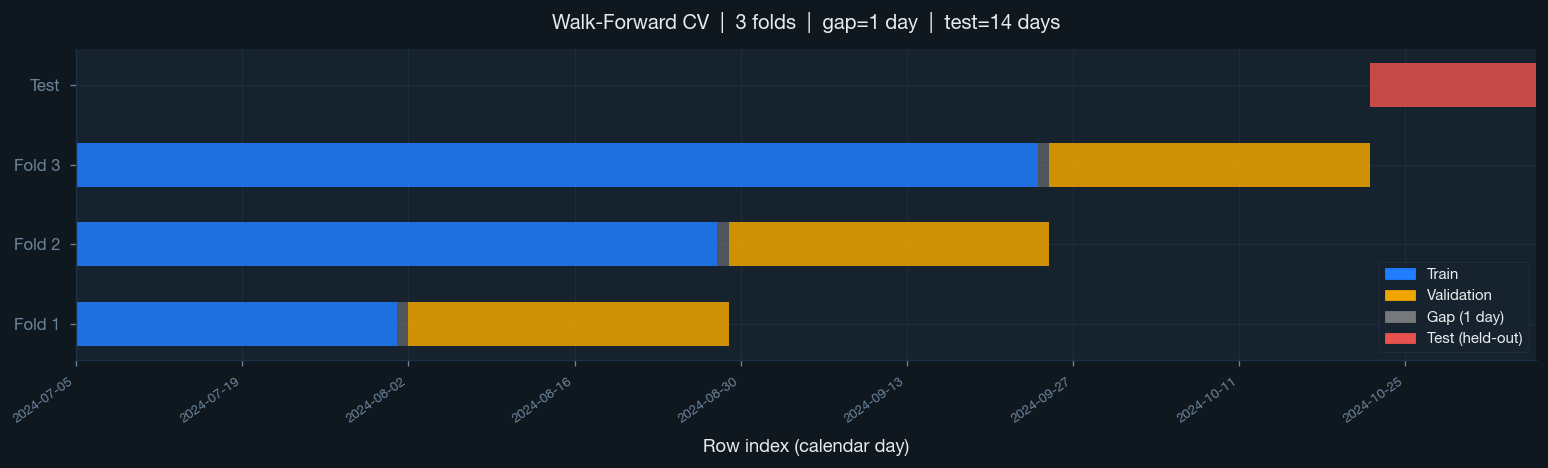

In [5]:
# ── Visualise the CV structure ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

dates = df_indexed.index
n     = len(dates)

TRAIN_CLR = DEMOCRAT
VAL_CLR   = "#f0a500"
TEST_CLR  = REPUBLICAN
GAP_CLR   = NEUTRAL

# Draw each fold as a horizontal bar
row_labels = []
for i, (tr, va) in enumerate(folds, 1):
    y = i
    # train
    ax.barh(y, tr[-1] - tr[0] + 1, left=tr[0], height=0.55, color=TRAIN_CLR, alpha=0.85)
    # gap (1 row)
    ax.barh(y, GAP, left=tr[-1] + 1, height=0.55, color=GAP_CLR, alpha=0.6)
    # val
    ax.barh(y, va[-1] - va[0] + 1, left=va[0], height=0.55, color=VAL_CLR, alpha=0.85)
    row_labels.append(f"Fold {i}")

# Test set
y = len(folds) + 1
ax.barh(y, test_idx[-1] - test_idx[0] + 1, left=test_idx[0], height=0.55, color=TEST_CLR, alpha=0.85)
row_labels.append("Test")

# Axis styling
ax.set_yticks(range(1, len(folds) + 2))
ax.set_yticklabels(row_labels, color=TEXT_PRIMARY, fontsize=10)
ax.set_xlim(0, n)

# Date ticks (every ~2 weeks)
tick_positions = range(0, n, 14)
tick_labels    = [str(dates[i].date()) for i in tick_positions if i < n]
ax.set_xticks(list(tick_positions)[:len(tick_labels)])
ax.set_xticklabels(tick_labels, rotation=35, ha="right", fontsize=8, color=TEXT_MUTED)

ax.set_xlabel("Row index (calendar day)", color=TEXT_PRIMARY)
ax.set_title(f"Walk-Forward CV  |  {N_SPLITS} folds  |  gap={GAP} day  |  test={TEST_DAYS} days",
             color=TEXT_PRIMARY, fontweight="bold", fontsize=12)

for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)

legend_handles = [
    mpatches.Patch(color=TRAIN_CLR, label="Train"),
    mpatches.Patch(color=VAL_CLR,   label="Validation"),
    mpatches.Patch(color=GAP_CLR,   label="Gap (1 day)"),
    mpatches.Patch(color=TEST_CLR,  label="Test (held-out)"),
]
ax.legend(handles=legend_handles, loc="lower right",
          facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=9)

plt.tight_layout()
plt.show()

## 3. Feature Selection

Feature selection is fitted **exclusively on the TV set** (rows 0 to `tv_idx[-1]`) to avoid leaking test-set information into the feature mask. The same mask is then applied to the full dataset.

Three sequential filters:

| Step | Method | Threshold | Purpose |
|---|---|---|---|
| 1 | Variance threshold | var < 1e-5 | Remove near-constant features (zero predictive signal) |
| 2 | Spearman correlation with target | \|ρ\| < 0.10 | Remove features with negligible monotonic relationship to the target |
| 3 | Pairwise correlation deduplication | \|ρ\| > 0.90 | Remove one of each highly correlated pair; keep the feature with the higher absolute Spearman correlation with the target |

> **Why Spearman?** Our features include bounded percentages, skewed volume counts, and probabilities. Spearman rank correlation is robust to non-normality and captures monotonic (not just linear) relationships — more appropriate here than Pearson.

> **Why threshold 0.10?** With ~109 TV observations, a Spearman |ρ| ≥ 0.10 corresponds to a two-tailed p-value of roughly 0.30 — a lenient threshold that only removes features with essentially zero relationship. This is intentional: let the models (regularised regression, trees) handle further selection.

In [6]:
# ── Working data: only feature columns (no date, no target) ───────────────────
feature_cols_all = [c for c in df_imp.columns if c not in [DATE_COL, TARGET_COL]]

# TV portion (indices into df_imp, which still has date as a column)
df_tv   = df_imp.iloc[tv_idx].reset_index(drop=True)
X_tv    = df_tv[feature_cols_all].values.astype(float)
y_tv    = df_tv[TARGET_COL].values.astype(float)

print(f"Feature matrix (TV): {X_tv.shape}  |  Target: {y_tv.shape}")
print(f"Starting features  : {X_tv.shape[1]}")

# ── Filter 1: Variance threshold ──────────────────────────────────────────────
VAR_THRESHOLD = 1e-5
variances     = X_tv.var(axis=0)
keep_var      = variances >= VAR_THRESHOLD
features_after_var = [f for f, k in zip(feature_cols_all, keep_var) if k]
removed_var        = [f for f, k in zip(feature_cols_all, keep_var) if not k]

print(f"\nFilter 1 — Variance threshold (var < {VAR_THRESHOLD}):")
print(f"  Removed : {len(removed_var)} features")
if removed_var:
    print(f"  Columns : {removed_var}")
print(f"  Kept    : {len(features_after_var)}")

# ── Filter 2: Spearman correlation with target ────────────────────────────────
SPEARMAN_THRESHOLD = 0.10
X_tv_f1 = df_tv[features_after_var].values.astype(float)

spearman_rs = np.array([
    abs(spearmanr(X_tv_f1[:, j], y_tv).statistic)
    for j in range(X_tv_f1.shape[1])
])

keep_spearman        = spearman_rs >= SPEARMAN_THRESHOLD
features_after_spear = [f for f, k in zip(features_after_var, keep_spearman) if k]
removed_spearman     = [f for f, k in zip(features_after_var, keep_spearman) if not k]

print(f"\nFilter 2 — Spearman |ρ| < {SPEARMAN_THRESHOLD} with target:")
print(f"  Removed : {len(removed_spearman)} features")
if removed_spearman:
    # Show top 10 removed with their correlation
    removed_with_r = sorted(
        [(f, r) for f, k, r in zip(features_after_var, keep_spearman, spearman_rs) if not k],
        key=lambda x: x[1], reverse=True
    )
    for fname, r in removed_with_r[:10]:
        print(f"    {fname:45s}  |ρ| = {r:.4f}")
    if len(removed_with_r) > 10:
        print(f"    ... and {len(removed_with_r)-10} more")
print(f"  Kept    : {len(features_after_spear)}")

Feature matrix (TV): (109, 196)  |  Target: (109,)
Starting features  : 196

Filter 1 — Variance threshold (var < 1e-05):
  Removed : 1 features
  Columns : ['reddit_election_disgust']
  Kept    : 195

Filter 2 — Spearman |ρ| < 0.1 with target:
  Removed : 74 features
    vader_compound_mean_cen                        |ρ| = 0.0997
    reddit_election_sent_avg                       |ρ| = 0.0994
    news_vader_leaning_gap_lag1                    |ρ| = 0.0959
    bsky_unique_authors                            |ρ| = 0.0957
    nrc_trust_rep                                  |ρ| = 0.0954
    bsky_avg_likes                                 |ρ| = 0.0946
    reddit_trump_unique_authors                    |ρ| = 0.0945
    bsky_total_posts                               |ρ| = 0.0940
    news_total                                     |ρ| = 0.0938
    sp500_return_1d                                |ρ| = 0.0929
    ... and 64 more
  Kept    : 121


In [7]:
# ── Filter 3: Pairwise correlation deduplication ─────────────────────────────
PAIRWISE_THRESHOLD = 0.90

X_tv_f2     = df_tv[features_after_spear].values.astype(float)
n_feat      = len(features_after_spear)

# Compute Spearman correlation with target (for tiebreaking)
feat_target_r = np.array([
    abs(spearmanr(X_tv_f2[:, j], y_tv).statistic)
    for j in range(n_feat)
])

# Compute pairwise Spearman correlation matrix
# (Using pandas .corr with Spearman method on TV data only)
df_feat_tv = pd.DataFrame(X_tv_f2, columns=features_after_spear)
corr_matrix = df_feat_tv.corr(method="spearman").abs()

# Greedy deduplication: iterate over all pairs above threshold
# For each correlated pair, drop the feature with lower |ρ| with target
dropped_pairwise = set()
feat_names = features_after_spear.copy()
feat_r_map = dict(zip(feat_names, feat_target_r))

for i in range(len(feat_names)):
    if feat_names[i] in dropped_pairwise:
        continue
    for j in range(i + 1, len(feat_names)):
        if feat_names[j] in dropped_pairwise:
            continue
        if corr_matrix.loc[feat_names[i], feat_names[j]] >= PAIRWISE_THRESHOLD:
            # Drop the one with lower |ρ| with target
            if feat_r_map[feat_names[i]] >= feat_r_map[feat_names[j]]:
                dropped_pairwise.add(feat_names[j])
            else:
                dropped_pairwise.add(feat_names[i])
                break  # feat_names[i] is dropped, skip remaining pairs

features_final = [f for f in feat_names if f not in dropped_pairwise]

print(f"Filter 3 — Pairwise deduplication (|ρ| > {PAIRWISE_THRESHOLD}):")
print(f"  Removed : {len(dropped_pairwise)} features")
if dropped_pairwise:
    for f in sorted(dropped_pairwise):
        print(f"    {f}")
print(f"  Kept    : {len(features_final)}")

print(f"\n{'='*55}")
print(f"Feature count  |  Start: {len(feature_cols_all):3d}")
print(f"               |  After variance  : {len(features_after_var):3d}  (−{len(removed_var):2d})")
print(f"               |  After Spearman  : {len(features_after_spear):3d}  (−{len(removed_spearman):2d})")
print(f"               |  After pairwise  : {len(features_final):3d}  (−{len(dropped_pairwise):2d})")
print(f"{'='*55}")

Filter 3 — Pairwise deduplication (|ρ| > 0.9):
  Removed : 9 features
    campaign_week
    gt_kamala_lag1
    news_attention_asymmetry_7d_lag1
    news_cen_count
    poll_market_divergence
    polymarket_trump_prob_lag2
    polymarket_trump_prob_lag3
    polymarket_trump_prob_lag5
    reddit_total_posts
  Kept    : 112

Feature count  |  Start: 196
               |  After variance  : 195  (− 1)
               |  After Spearman  : 121  (−74)
               |  After pairwise  : 112  (− 9)


In [8]:
# ── Top features by Spearman |ρ| with target ─────────────────────────────────
final_r = {f: abs(spearmanr(df_tv[f].values, y_tv).statistic) for f in features_final}
top_feats = sorted(final_r.items(), key=lambda x: x[1], reverse=True)

print(f"Top 20 selected features by |Spearman ρ| with {TARGET_COL} (TV set):")
print(f"{'Rank':>4}  {'Feature':50s}  |ρ|")
print("-" * 65)
for rank, (feat, r) in enumerate(top_feats[:20], 1):
    print(f"{rank:>4}  {feat:50s}  {r:.4f}")

print(f"\n... and {max(0, len(top_feats) - 20)} more selected features not shown.")

Top 20 selected features by |Spearman ρ| with polymarket_trump_prob (TV set):
Rank  Feature                                             |ρ|
-----------------------------------------------------------------
   1  polymarket_trump_prob_lag1                          0.9566
   2  polymarket_trump_prob_lag4                          0.8440
   3  poll_market_divergence_lag1                         0.7758
   4  bond_10y                                            0.7476
   5  usd_index                                           0.7231
   6  poll_margin_7d_avg                                  0.6204
   7  reddit_harris_trust                                 0.5517
   8  bsky_harris_sent_avg                                0.5355
   9  poll_margin                                         0.5166
  10  poll_margin_lag1                                    0.4980
  11  bsky_harris_neg_share                               0.4497
  12  bsky_harris_pos_share                               0.4425
  13  bsky_tru

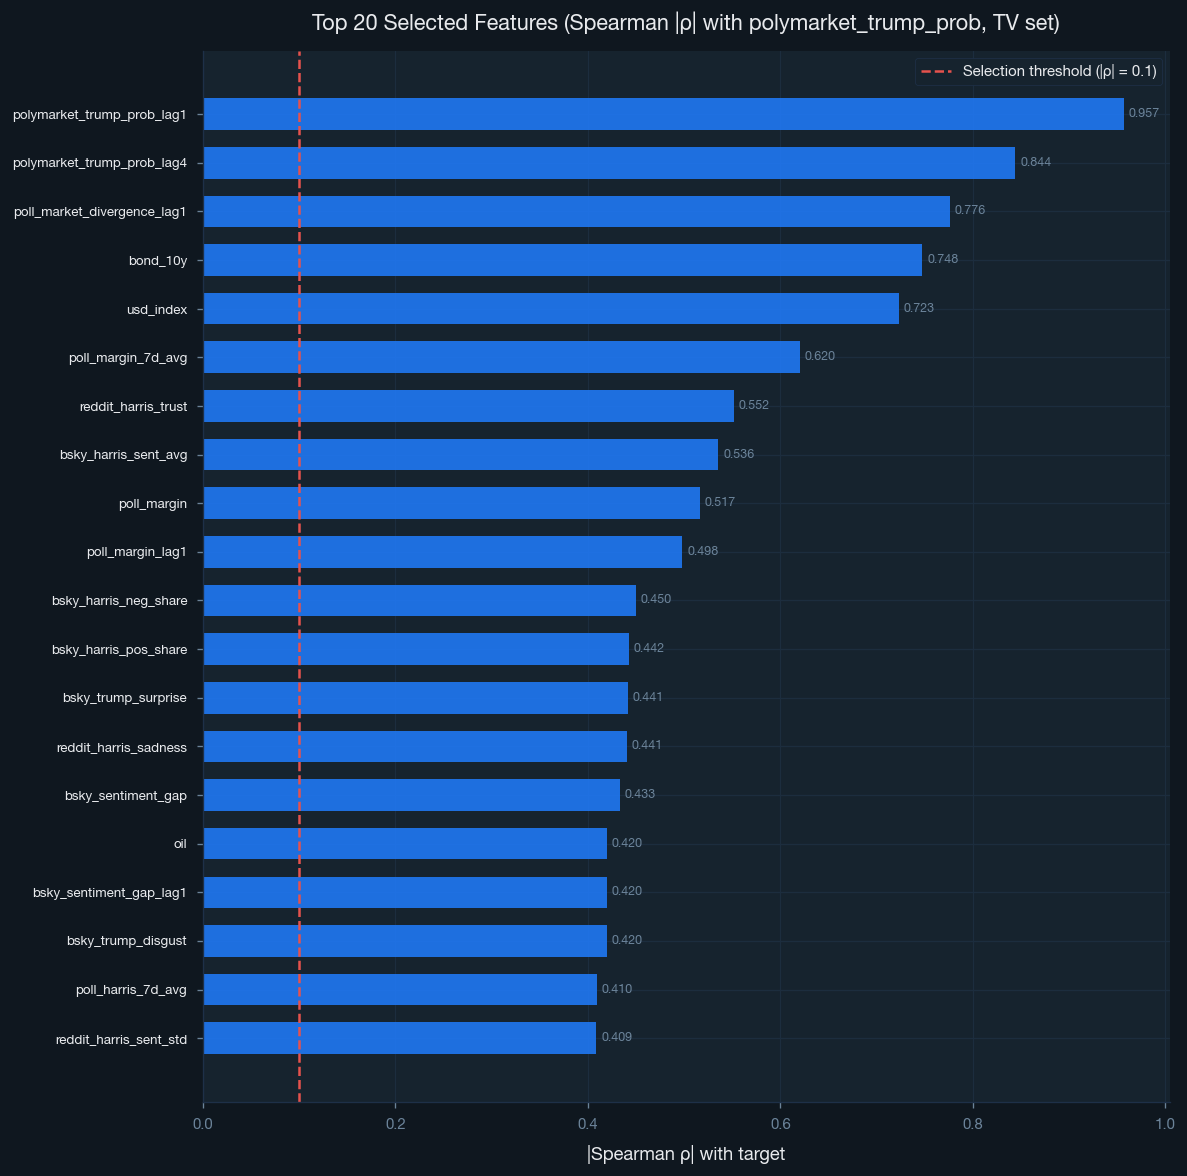

In [9]:
# ── Bar chart: top 20 selected features ───────────────────────────────────────
N_SHOW = min(20, len(top_feats))
show_feats = top_feats[:N_SHOW]

fig, ax = plt.subplots(figsize=(10, 0.42 * N_SHOW + 1.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

names = [f for f, _ in show_feats[::-1]]
rs    = [r for _, r in show_feats[::-1]]
colors = [DEMOCRAT if r >= 0.30 else ("#f0a500" if r >= 0.15 else NEUTRAL) for r in rs]

bars = ax.barh(names, rs, color=colors, alpha=0.85, height=0.65)
ax.axvline(SPEARMAN_THRESHOLD, color=REPUBLICAN, linestyle="--", linewidth=1.5,
           label=f"Selection threshold (|ρ| = {SPEARMAN_THRESHOLD})")

for bar, r in zip(bars, rs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{r:.3f}", va="center", ha="left", fontsize=7.5, color=TEXT_MUTED)

ax.set_xlabel("|Spearman ρ| with target", color=TEXT_PRIMARY)
ax.set_title(f"Top {N_SHOW} Selected Features (Spearman |ρ| with {TARGET_COL}, TV set)",
             color=TEXT_PRIMARY, fontweight="bold")

for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COLOR)
ax.tick_params(colors=TEXT_MUTED)
ax.set_yticklabels(names, fontsize=8, color=TEXT_PRIMARY)
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=9)

plt.tight_layout()
plt.show()

## 4. Save Preprocessed Basetable

The final basetable contains:
- `date` — index column
- `polymarket_trump_prob` — target
- All selected feature columns

In [10]:
# ── Assemble final basetable ───────────────────────────────────────────────────
output_cols = [DATE_COL, TARGET_COL] + features_final
basetable   = df_imp[output_cols].copy()

# Final sanity checks
assert basetable.isna().sum().sum() == 0,    "NaN still present!"
assert TARGET_COL in basetable.columns,      "Target column missing!"
assert basetable[DATE_COL].is_monotonic_increasing, "Dates not sorted!"

# Verify test set is untouched (no leakage from feature selection)
# Feature mask was derived from TV only → test rows just get the same columns
tv_end_date   = basetable[DATE_COL].iloc[tv_idx[-1]]
test_start_dt = basetable[DATE_COL].iloc[test_idx[0]]
assert test_start_dt > tv_end_date, "Test set boundary violated!"

basetable.to_csv(OUTPUT_CSV, index=False)

print("Preprocessed basetable saved to:")
print(f"  {os.path.abspath(OUTPUT_CSV)}")
print()
print(f"  Rows     : {len(basetable)}")
print(f"  Columns  : {basetable.shape[1]}  (date + target + {len(features_final)} features)")
print(f"  TV rows  : {len(tv_idx)} ({basetable[DATE_COL].iloc[tv_idx[0]].date()} → {tv_end_date.date()})")
print(f"  Test rows: {len(test_idx)} ({test_start_dt.date()} → {basetable[DATE_COL].iloc[-1].date()})")
print(f"  NaN total: {basetable.isna().sum().sum()}")
print()
print("Ready for modelling. Use Functions/data_splits.py to recreate CV folds.")

Preprocessed basetable saved to:
  /Users/helenalips/Desktop/HIR 1ste master/Social Media and Web Analytics/group-project-SMWA/Data/3_Gold/basetable_preprocessed.csv

  Rows     : 123
  Columns  : 114  (date + target + 112 features)
  TV rows  : 109 (2024-07-05 → 2024-10-21)
  Test rows: 14 (2024-10-22 → 2024-11-04)
  NaN total: 0

Ready for modelling. Use Functions/data_splits.py to recreate CV folds.


In [11]:
basetable.head()

,date,polymarket_trump_prob,polymarket_trump_prob_lag1,days_to_election,bsky_trump_unique_authors,bsky_harris_unique_authors,bsky_trump_share,bsky_harris_share,bsky_posts_per_author,bsky_trump_fear,...,vix_change_1d,polymarket_trump_prob_lag4,price_change_lag1,bsky_sentiment_gap_lag1,poll_margin_lag1,poll_market_divergence_lag1,gt_trump_lag1,gt_trump_share_lag1,vix_lag1,reddit_sentiment_gap_lag1
0,2024-07-05,0.625,0.605,123.0,12.0,12.0,0.341463,0.341463,1.366667,0.073353,...,0.389999,0.650,0.00,0.000000,0.0,0.0,0.0,0.00,0.00,0.000000
1,2024-07-06,0.625,0.625,122.0,10.0,11.0,0.416667,0.500000,1.200000,0.109973,...,0.389999,0.615,0.02,-0.547041,0.0,0.0,3.0,0.75,12.48,-0.063879
2,2024-07-07,0.605,0.625,121.0,11.0,6.0,0.448276,0.413793,1.705882,0.051515,...,0.389999,0.605,0.00,-0.236525,-1.0,21.5,3.0,1.00,12.48,-0.078085
3,2024-07-08,0.625,0.605,120.0,12.0,7.0,0.480000,0.400000,1.388889,0.076709,...,-0.110000,0.605,-0.02,-0.549087,-1.0,21.5,2.0,1.00,12.48,-0.087317
4,2024-07-09,0.625,0.625,119.0,12.0,10.0,0.410256,0.435897,1.695652,0.046917,...,0.140000,0.625,0.02,-0.340401,6.0,11.5,2.0,1.00,12.37,-0.078122


In [12]:
# ── Summary of selected features by group ─────────────────────────────────────
groups = {
    "Polymarket lags"     : [f for f in features_final if f.startswith("polymarket")],
    "Time"                : [f for f in features_final if f in [
                                "days_to_election", "is_weekend", "weekday",
                                "campaign_week", "days_since_last_event"]],
    "Bluesky"             : [f for f in features_final if f.startswith("bsky_")],
    "Reddit"              : [f for f in features_final if f.startswith("reddit_")],
    "News volume"         : [f for f in features_final if f.startswith("news_")],
    "News sentiment"      : [f for f in features_final
                                if f.startswith(("vader_", "nrc_"))],
    "Google Trends"       : [f for f in features_final if f.startswith("gt_")],
    "Polls"               : [f for f in features_final if f.startswith("poll_")],
    "Financial"           : [f for f in features_final
                                if f in ["sp500", "oil", "vix", "bond_10y", "usd_index",
                                         "sp500_return_1d", "sp500_return_7d", "sp500_vol_7d",
                                         "oil_return_1d", "vix_change_1d",
                                         "vix_lag1", "sp500_return_1d_lag1"]],
    "Cross-source lags"   : [f for f in features_final
                                if f.endswith("_lag1") and not f.startswith("polymarket")
                                and f not in ["vix_lag1", "sp500_return_1d_lag1"]],
    "Price change lags"   : [f for f in features_final if f.startswith("price_change_")],
}

accounted = set(f for lst in groups.values() for f in lst)
other     = [f for f in features_final if f not in accounted]
if other:
    groups["Other"] = other

print(f"{'Group':25s}  #features")
print("-" * 40)
total = 0
for grp, feats in groups.items():
    print(f"  {grp:23s}  {len(feats):3d}")
    total += len(feats)
print("-" * 40)
print(f"  {'Total':23s}  {total:3d}")

Group                      #features
----------------------------------------
  Polymarket lags            2
  Time                       1
  Bluesky                   28
  Reddit                    33
  News volume                3
  News sentiment            16
  Google Trends             10
  Polls                      9
  Financial                  9
  Cross-source lags          7
  Price change lags          1
----------------------------------------
  Total                    119
